# Determining Job Candidates

## Objective
Build a model that can predict whether or not potential job candidates are interested in taking a new job.

## Data Dictionary
<ul>
    <li><b>enrollee_id</b>: Unique ID for the candidate</li>
    <li><b>city</b>: City code</li>
    <li><b>city_development_code</b>: Development index of the city (scaled)</li>
    <li><b>gender</b>: Gender of the candidate</li>
    <li><b>relevent_experience</b>: Relevant experience of the candidate in years</li>
    <li><b>enrolled_university</b>: Type of University course enrolled, if any</li>
    <li><b>education_level</b>: Education level of the candidate</li>
    <li><b>major_discipline</b>: Education major discipline of the candidate</li>
    <li><b>experience</b>: Candidate total experience in years</li>
    <li><b>company_size</b>: No. of employees in current employer's company</li>
    <li><b>company_type</b>: Type of current employer</li>
    <li><b>lastnewjob</b>: Difference in years between previous job and current job</li>
    <li><b>training_hours</b>: Training hours completed</li>
    <li><b>target</b>: 0 - Not looking for a job change, 1 - Looking for a job change</li>
</ul>

### Load libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Make sure you have all the libraries that we will be using
import pandas as pd
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
#To install xgboost library use - !pip install xgboost 
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

### Load Data

In [2]:
df = pd.read_csv("job_candidates.csv")

## Data Overview

In [3]:
df.sample(10)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
1986,16781,city_16,0.910,NaN,Has relevent experience,no_enrollment,Graduate,STEM,>20,10/49,Pvt Ltd,1,30,0.0
10288,7744,city_45,0.890,Male,Has relevent experience,Part time course,Graduate,STEM,7,50-99,Early Stage Startup,1,31,0.0
2856,23534,city_103,0.920,Male,No relevent experience,Full time course,High School,NaN,6,50-99,Public Sector,2,111,1.0
7291,26341,city_160,0.920,Male,No relevent experience,no_enrollment,Graduate,STEM,16,10000+,NaN,1,24,0.0
15833,31403,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,Humanities,5,50-99,Pvt Ltd,1,46,0.0
13687,28940,city_103,0.920,NaN,No relevent experience,no_enrollment,Graduate,Arts,14,NaN,Funded Startup,1,24,0.0
15452,16444,city_21,0.624,NaN,Has relevent experience,no_enrollment,High School,NaN,3,NaN,NaN,1,27,1.0
18859,14469,city_74,0.579,Male,Has relevent experience,no_enrollment,Graduate,STEM,5,100-500,Pvt Ltd,1,34,1.0
6501,33154,city_21,0.624,Male,No relevent experience,Full time course,High School,NaN,3,NaN,NaN,never,148,1.0
17117,11946,city_21,0.624,NaN,No relevent experience,no_enrollment,Graduate,STEM,5,50-99,Pvt Ltd,>4,43,1.0


Several NaN values are easily visible

In [4]:
df.shape

(19158, 14)

- 19158 rows and 14 columns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

<b>Numeric Features:</b>
<ul>
    <li>city_development_index</li>
    <li>training_hours</li>
</ul>
<b>Categorical Features:</b>
<ul>
    <li>city</li>
    <li>gender</li>
    <li>relevent_experience</li>
    <li>enrolled_university</li>
    <li>education_level</li>
    <li>major_discipline</li>
    <li>experience</li>
    <li>company_size</li>
    <li>company_type</li>
    <li>last_new_job</li>
</ul>

In [6]:
# Checking for duplicate rows
df.duplicated().sum()

0

In [7]:
# Number of missing values in each row
df.isna().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
enrollee_id,19158.0,16875.358179,9616.292592,1.000,8554.25,16982.500,25169.75,33380.000
city_development_index,19158.0,0.828848,0.123362,0.448,0.74,0.903,0.92,0.949
training_hours,19158.0,65.366896,60.058462,1.000,23.00,47.000,88.00,336.000
target,19158.0,0.249348,0.432647,0.000,0.00,0.000,0.00,1.000


In [9]:
df.nunique()

enrollee_id               19158
city                        123
city_development_index       93
gender                        3
relevent_experience           2
enrolled_university           3
education_level               5
major_discipline              6
experience                   22
company_size                  8
company_type                  6
last_new_job                  6
training_hours              241
target                        2
dtype: int64

Many uniques for numerical columns, which is unsurprising, but also 22 unique values for experience.

In [10]:
df['target'].value_counts()

target
0.0    14381
1.0     4777
Name: count, dtype: int64

<b>Observations:<b>
<ul>
    <li>Vast majority of candidates were uninterested in a job change.</li>
    <li>There are many unique values for 'experience', which is strange for a categorical column</li>
    <li>city_development_index is already scaled, so there are no apparent outliers</li>
    <li>There are clearly outliers in training_hours</li>
    <li>There are many null values throughout the dataframe, but especially in company_type, company_size, gender, and major_discipline.</li>
</ul>

## Data Preprocessing

First, we need should remove enrollee_id and city, as they are useless for the purpose of this data.

In [11]:
df = df.drop(['enrollee_id'], axis=1)
df = df.drop(['city'], axis=1)

In [12]:
df.sample(5)

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
15585,0.910,Male,Has relevent experience,no_enrollment,Graduate,Humanities,7,50-99,Pvt Ltd,>4,146,0.0
14888,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,>4,8,0.0
14573,0.624,Male,No relevent experience,Full time course,High School,NaN,5,NaN,NaN,1,222,1.0
13159,0.923,Female,Has relevent experience,no_enrollment,Phd,STEM,11,5000-9999,Pvt Ltd,1,54,0.0
15024,0.827,Male,Has relevent experience,no_enrollment,NaN,NaN,10,50-99,Pvt Ltd,3,36,0.0


### Missing Values

In [13]:
df.isna().sum()

city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [14]:
# Getting number of rows with 1-12 missing values
for i in range(len(list(df.columns.values))):
    data = df[df.isnull().sum(axis=1) == i]
    print(f"Number of rows with {i} missing value(s): {len(data.index)}")

Number of rows with 0 missing value(s): 8955
Number of rows with 1 missing value(s): 3718
Number of rows with 2 missing value(s): 3654
Number of rows with 3 missing value(s): 1953
Number of rows with 4 missing value(s): 628
Number of rows with 5 missing value(s): 176
Number of rows with 6 missing value(s): 62
Number of rows with 7 missing value(s): 12
Number of rows with 8 missing value(s): 0
Number of rows with 9 missing value(s): 0
Number of rows with 10 missing value(s): 0
Number of rows with 11 missing value(s): 0


In [15]:
# Investigating rows with 6 and 7 missing values
data = df[df.isnull().sum(axis=1) == 7]
data.head(20)

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
1376,0.920,NaN,Has relevent experience,NaN,NaN,NaN,6,NaN,NaN,NaN,156,0.0
2518,0.897,NaN,No relevent experience,NaN,NaN,NaN,4,NaN,NaN,NaN,222,0.0
7746,0.624,NaN,No relevent experience,NaN,NaN,NaN,5,NaN,NaN,NaN,98,0.0
8905,0.925,NaN,No relevent experience,NaN,NaN,NaN,4,NaN,NaN,NaN,53,0.0
9206,0.920,NaN,No relevent experience,NaN,NaN,NaN,4,NaN,NaN,NaN,138,0.0
10337,0.887,NaN,No relevent experience,NaN,NaN,NaN,>20,NaN,NaN,NaN,39,1.0
11789,0.897,NaN,No relevent experience,NaN,NaN,NaN,4,NaN,NaN,NaN,22,0.0
12079,0.698,NaN,No relevent experience,NaN,NaN,NaN,2,NaN,NaN,NaN,97,0.0
12348,0.920,NaN,No relevent experience,NaN,NaN,NaN,<1,NaN,NaN,NaN,43,0.0
13236,0.920,NaN,Has relevent experience,NaN,NaN,NaN,>20,NaN,NaN,NaN,21,0.0


Truthfully, when there are this many missing values in a row, it should simply be dropped, rather than trying to replace those that are missing. The same goes for rows with 5 or 6 missing values as well. So, such rows will be dropped.

In [16]:
# Removing rows with 5 or more missing values
df = df[df.isnull().sum(axis=1) <= 4]
df.shape

(18908, 12)

In [17]:
# Checking number of rows with 1-12 missing values
for i in range(len(list(df.columns.values))):
    data = df[df.isnull().sum(axis=1) == i]
    print(f"Number of rows with {i} missing value(s): {len(data.index)}")

Number of rows with 0 missing value(s): 8955
Number of rows with 1 missing value(s): 3718
Number of rows with 2 missing value(s): 3654
Number of rows with 3 missing value(s): 1953
Number of rows with 4 missing value(s): 628
Number of rows with 5 missing value(s): 0
Number of rows with 6 missing value(s): 0
Number of rows with 7 missing value(s): 0
Number of rows with 8 missing value(s): 0
Number of rows with 9 missing value(s): 0
Number of rows with 10 missing value(s): 0
Number of rows with 11 missing value(s): 0


In [18]:
df.isna().sum()

city_development_index       0
gender                    4300
relevent_experience          0
enrolled_university        271
education_level            284
major_discipline          2572
experience                  46
company_size              5695
company_type              5894
last_new_job               335
training_hours               0
target                       0
dtype: int64

Before proceeding any further with removing the null values, we should investigate the dataframe, and see if there is a correlation between missing values.

In [19]:
df[df['gender'].isnull()].isna().sum()

city_development_index       0
gender                    4300
relevent_experience          0
enrolled_university         97
education_level             66
major_discipline           636
experience                  34
company_size              1423
company_type              1503
last_new_job               266
training_hours               0
target                       0
dtype: int64

In [20]:
df[df['enrolled_university'].isnull()].isna().sum()

city_development_index      0
gender                     97
relevent_experience         0
enrolled_university       271
education_level            11
major_discipline           47
experience                  2
company_size              124
company_type              131
last_new_job                9
training_hours              0
target                      0
dtype: int64

In [21]:
df[df['education_level'].isnull()].isna().sum()

city_development_index      0
gender                     66
relevent_experience         0
enrolled_university        11
education_level           284
major_discipline          284
experience                  0
company_size              135
company_type              129
last_new_job                6
training_hours              0
target                      0
dtype: int64

When education_level is null, so is major_discipline, which isn't terribly surprising.

In [22]:
df[df['experience'].isnull()].isna().sum()

city_development_index     0
gender                    34
relevent_experience        0
enrolled_university        2
education_level            0
major_discipline           3
experience                46
company_size               8
company_type              17
last_new_job              15
training_hours             0
target                     0
dtype: int64

In [23]:
df[df['company_size'].isnull()].isna().sum()

city_development_index       0
gender                    1423
relevent_experience          0
enrolled_university        124
education_level            135
major_discipline          1490
experience                   8
company_size              5695
company_type              5121
last_new_job               123
training_hours               0
target                       0
dtype: int64

In [24]:
df[df['company_type'].isnull()].isna().sum()

city_development_index       0
gender                    1503
relevent_experience          0
enrolled_university        131
education_level            129
major_discipline          1412
experience                  17
company_size              5121
company_type              5894
last_new_job               153
training_hours               0
target                       0
dtype: int64

In [25]:
df[df['last_new_job'].isnull()].isna().sum()

city_development_index      0
gender                    266
relevent_experience         0
enrolled_university         9
education_level             6
major_discipline           36
experience                 15
company_size              123
company_type              153
last_new_job              335
training_hours              0
target                      0
dtype: int64

There don't appear to be any other obvious correlations

#### education_level & major_discipline

Since every column seems reasonably likely to be a predictor for the target variable, I believe each column's missing values should be handled independantly.

In [26]:
df.isna().sum()

city_development_index       0
gender                    4300
relevent_experience          0
enrolled_university        271
education_level            284
major_discipline          2572
experience                  46
company_size              5695
company_type              5894
last_new_job               335
training_hours               0
target                       0
dtype: int64

#### gender

In [27]:
df.gender.value_counts()

gender
Male      13185
Female     1237
Other       186
Name: count, dtype: int64

Originally, I was going to replace missing values with each of the three unique values for the column, at the same distribution as rows that are non-null. However, the function I made for this currently doesn't work, because of a version dispute between libraries, so I will just replace missing values with "Unknown", to save time. This isn't a terrible solution, as there are a vast number of missing values in the column, which makes it difficult to take value from it.

In [28]:
df.loc[df.gender.isnull(), 'gender'] = "Unknown"

In [29]:
df.shape

(18908, 12)

#### enrolled_university

In [30]:
df.enrolled_university.value_counts()

enrolled_university
no_enrollment       13729
Full time course     3719
Part time course     1189
Name: count, dtype: int64

In [31]:
df.enrolled_university.isna().sum()

271

Unlike gender, there aren't that many missing values for this column, relatively speaking, so it would be acceptable to simply replace them with the mode.

In [32]:
df.loc[df.enrolled_university.isnull(), 'enrolled_university'] = 'no_enrollment'

In [33]:
df.enrolled_university.value_counts()

enrolled_university
no_enrollment       14000
Full time course     3719
Part time course     1189
Name: count, dtype: int64

#### education_level

In [34]:
df.education_level.value_counts()

education_level
Graduate          11591
Masters            4357
High School        1963
Phd                 413
Primary School      300
Name: count, dtype: int64

In [35]:
df.education_level.isna().sum()

284

As with enrolled_university, the missing values here will be replaced with the mode.

In [36]:
df.loc[df.education_level.isnull(), 'education_level'] = 'Graduate'

In [37]:
df.education_level.value_counts()

education_level
Graduate          11875
Masters            4357
High School        1963
Phd                 413
Primary School      300
Name: count, dtype: int64

#### major_discipline

In [38]:
df.major_discipline.value_counts()

major_discipline
STEM               14483
Humanities           669
Other                381
Business Degree      327
Arts                 253
No Major             223
Name: count, dtype: int64

In [39]:
df.major_discipline.isna().sum()

2572

There are a comparable number of missing values in this column as there are in gender, so they will also be replaced with "Unknown".

In [40]:
df.loc[df.major_discipline.isnull(), 'major_discipline'] = "Unknown"

In [41]:
df.major_discipline.value_counts()

major_discipline
STEM               14483
Unknown             2572
Humanities           669
Other                381
Business Degree      327
Arts                 253
No Major             223
Name: count, dtype: int64

#### experience

In [42]:
df.experience.value_counts()

experience
>20    3269
5      1411
4      1381
3      1321
6      1204
2      1080
7      1023
10      985
9       976
8       795
15      683
11      662
14      586
1       526
16      505
<1      498
12      491
13      398
17      341
19      303
18      278
20      146
Name: count, dtype: int64

In [43]:
df.experience.isna().sum()

46

There are not many rows with missing values in this column, so replacing with mode is fine.

In [44]:
df.loc[df.experience.isnull(), 'experience'] = '>20'

In [45]:
df.experience.value_counts()

experience
>20    3315
5      1411
4      1381
3      1321
6      1204
2      1080
7      1023
10      985
9       976
8       795
15      683
11      662
14      586
1       526
16      505
<1      498
12      491
13      398
17      341
19      303
18      278
20      146
Name: count, dtype: int64

#### company_size

In [46]:
df.company_size.value_counts()

company_size
50-99        3083
100-500      2568
10000+       2018
10/49        1469
1000-4999    1328
<10          1307
500-999       877
5000-9999     563
Name: count, dtype: int64

In [47]:
df.company_size.isna().sum()

5695

Unfortunately, there are too many missing values in this column for it to prove helpful as a predictor, so the column will simply be dropped.

In [48]:
df = df.drop('company_size', axis=1)

In [49]:
df.isna().sum()

city_development_index       0
gender                       0
relevent_experience          0
enrolled_university          0
education_level              0
major_discipline             0
experience                   0
company_type              5894
last_new_job               335
training_hours               0
target                       0
dtype: int64

#### company_type

In [50]:
df.company_type.value_counts()

company_type
Pvt Ltd                9814
Funded Startup         1001
Public Sector           954
Early Stage Startup     603
NGO                     521
Other                   121
Name: count, dtype: int64

In [51]:
df.company_type.isna().sum()

5894

Similarly to company_size, there are too many missing values in the column, so it will be dropped. 

In [52]:
df = df.drop('company_type', axis=1)

In [53]:
df.isna().sum()

city_development_index      0
gender                      0
relevent_experience         0
enrolled_university         0
education_level             0
major_discipline            0
experience                  0
last_new_job              335
training_hours              0
target                      0
dtype: int64

#### last_new_job

In [54]:
df.last_new_job.value_counts()

last_new_job
1        8004
>4       3279
2        2890
never    2351
4        1028
3        1021
Name: count, dtype: int64

In [55]:
df.last_new_job.isna().sum()

335

There are not many missing values in this column, so they will be replaced with the mode.

In [56]:
df.loc[df.last_new_job.isnull(), 'last_new_job'] = '1'

In [57]:
df.isna().sum()

city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
last_new_job              0
training_hours            0
target                    0
dtype: int64

### Outliers

In [58]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
city_development_index,18908.0,0.829421,0.123049,0.448,0.74,0.91,0.92,0.949
training_hours,18908.0,65.379945,60.065504,1.000,23.00,47.00,88.00,336.000
target,18908.0,0.249524,0.432749,0.000,0.00,0.00,0.00,1.000


As stated earlier, at a glance, it appears as though <b>training_hours</b> is the only column with any outliers, so let's take a look at it.

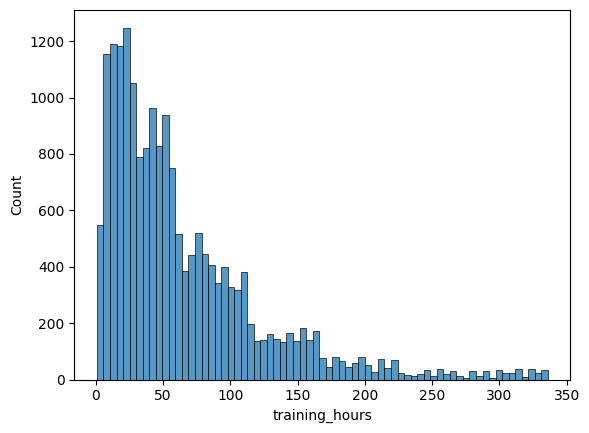

In [59]:
sns.histplot(df['training_hours']);

As shown by the histogram, while there are a number of rows with values above the upper fence, they are gradually descending in count, and there are no particular values that are considerably far away from a neighbor. This leads me to believe that even values outside of the upper fence are believable, and as such they will not be touched.

### Inconsistent Data

Thankfully, many of the columns were already checked, when investigating them for missing values.

<b>Column to Check:</b>
<ul>
    <li>relevent_experience</li>
</ul>

In [60]:
print(f"{df['relevent_experience'].value_counts()} \n")

relevent_experience
Has relevent experience    13734
No relevent experience      5174
Name: count, dtype: int64 



There is no inconsistent data.

## Exploratory Data Analysis

In [61]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    data[feature].describe()
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [62]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [63]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [64]:
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Univariate Analysis

#### Categorical Features:
<ul>
    <li>gender</li>
    <li>relevent_experience</li>
    <li>enrolled_university</li>
    <li>education_level</li>
    <li>major_discipline</li>
    <li>experience</li>
    <li>last_new_job</li>
</ul>

<b>gender</b>

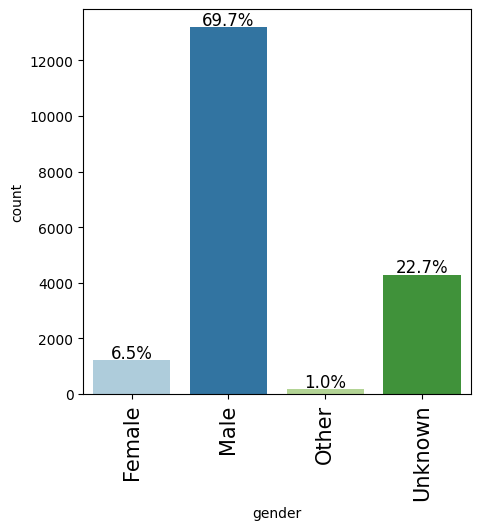

In [65]:
labeled_barplot(df, 'gender', perc=True)

<b>Observation(s):</b>
<ul>
    <li>Vast majority of candidates were male</li>
    <li>Gender was more than three times as likely to be Unknown than Female</li>
</ul>

<b>relevent_experience</b>

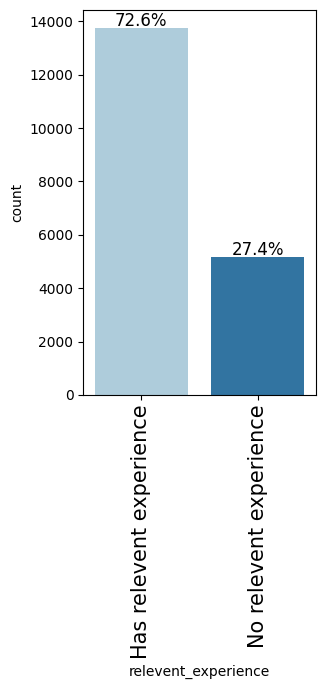

In [66]:
labeled_barplot(df, 'relevent_experience', perc=True)

<b>Observation(s):</b>
<ul>
    <li>More candidates had relevant experience</li>
</ul>

<b>enrolled_university</b>

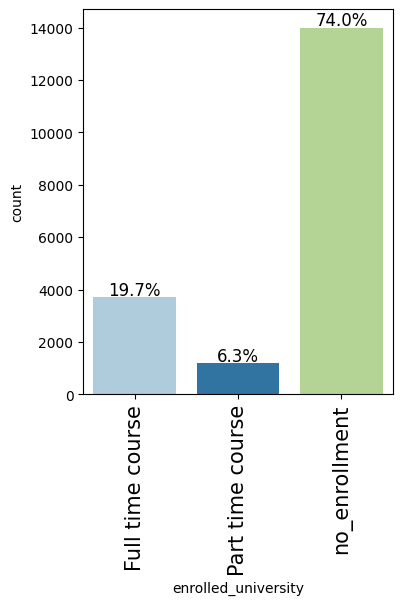

In [67]:
labeled_barplot(df, 'enrolled_university', perc=True)

<b>Observation(s):</b>
<ul>
    <li>Most candidates were not enrolled</li>
    <li>More candidates were enrolled full-time than part-time</li>
</ul>

<b>education_level</b>

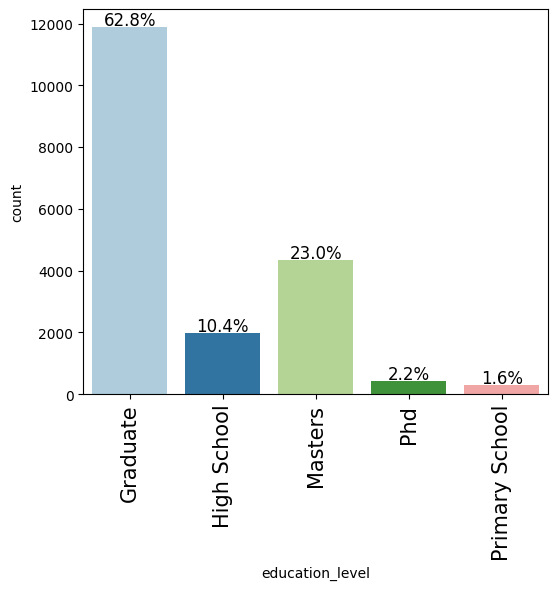

In [68]:
labeled_barplot(df, 'education_level', perc=True)

<b>Observation(s):</b>
<ul>
    <li>Most candidates were college graduates</li>
    <li>Masters > high school > phd > primary school</li>
</ul>

<b>major_discipline</b>

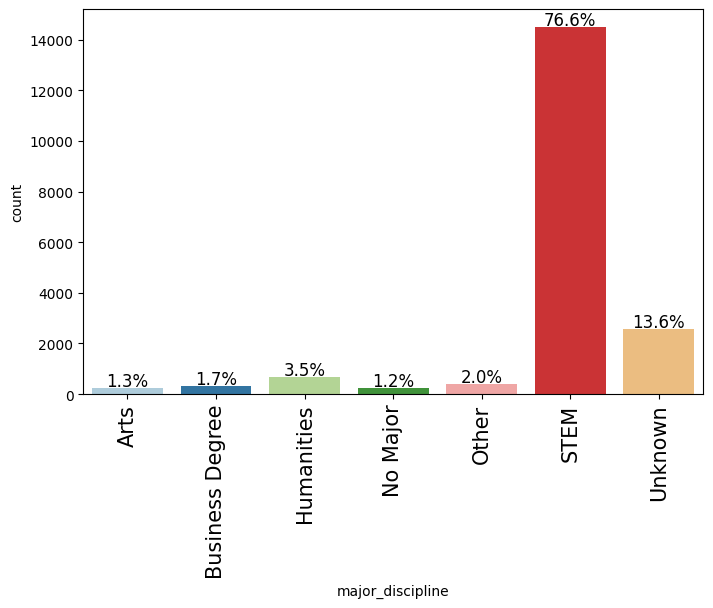

In [69]:
labeled_barplot(df, 'major_discipline', perc=True)

<b>Observation(s):</b>
<ul>
    <li>Vast majority of candidates were in STEM</li>
    <li>Others are similarly frequent, aside from unknown</li>
</ul>

<b>experience</b>

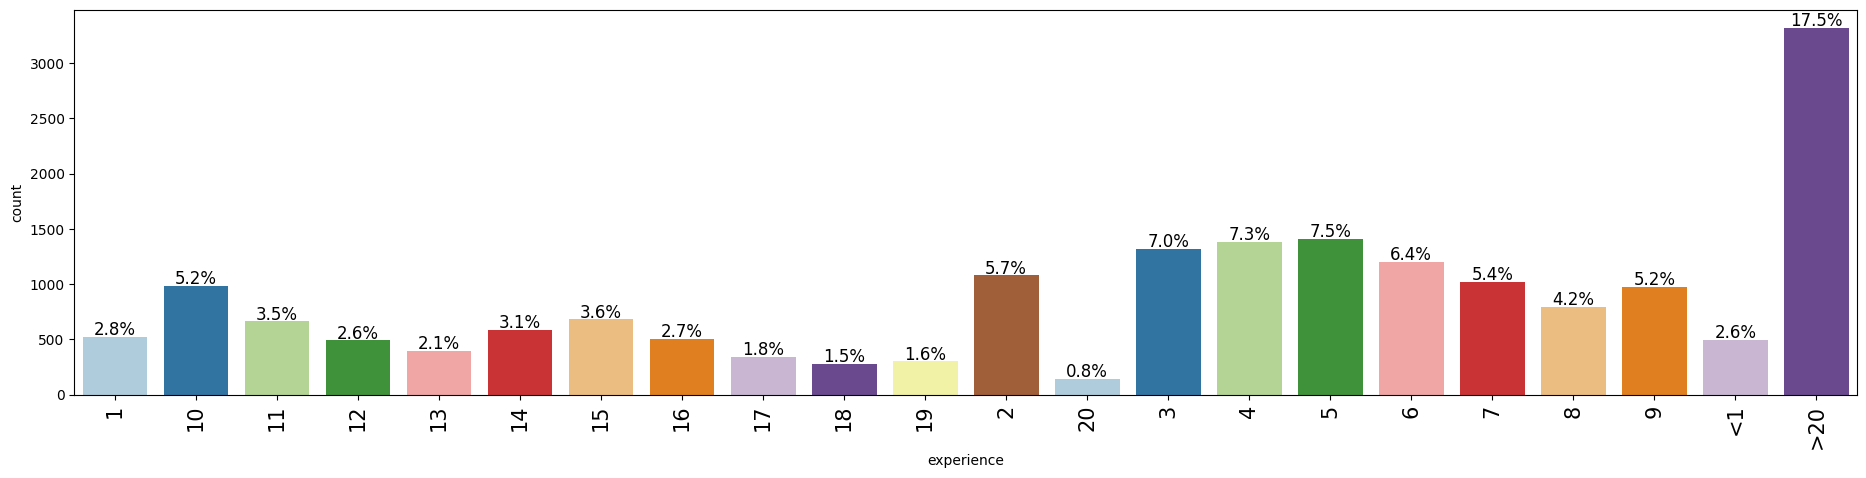

In [70]:
labeled_barplot(df, 'experience', perc=True)

<b>Observation(s):</b>
<ul>
    <li>Most candidates had more than 20 years of experience</li>
    <li>Lowest count of experience was exactly 20 years</li>
</ul>

<b>last_new_job</b>

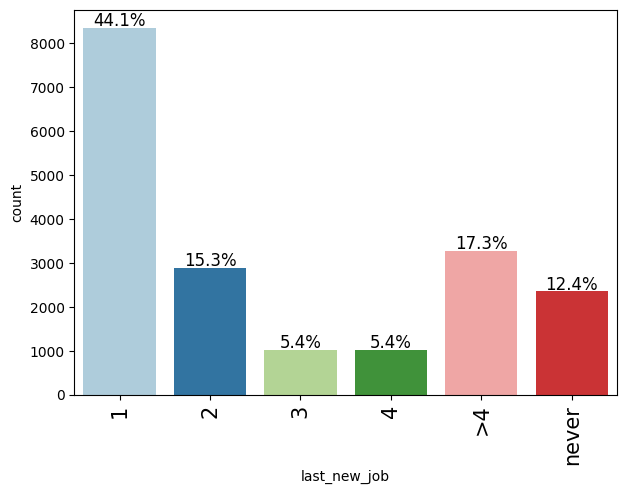

In [71]:
labeled_barplot(df, 'experience', perc=True)

<b>Observation(s):</b>
<ul>
    <li>Most candidates are a year apart from their previous job</li>
    <li>2, >4, and never were similarly likely</li>
    <li>3 and 4 are equally likely</li>
</ul>

#### Numerical Features:
<ul>
    <li>city_development_index</li>
    <li>training_hours</li>
</ul>

<b>city_development_index</b>

In [72]:
df['city_development_index'].describe()

count    18908.000000
mean         0.829421
std          0.123049
min          0.448000
25%          0.740000
50%          0.910000
75%          0.920000
max          0.949000
Name: city_development_index, dtype: float64

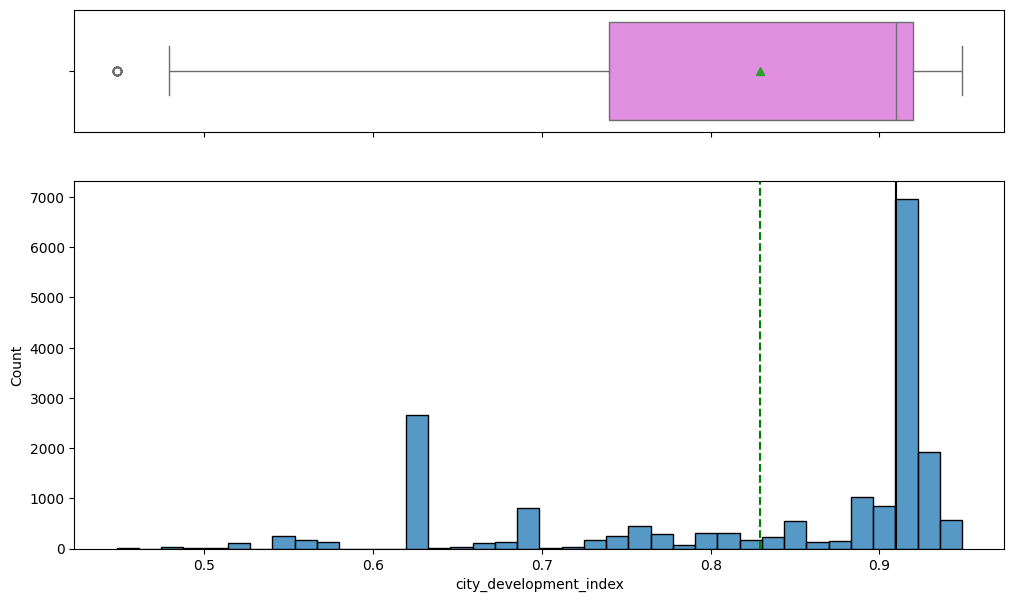

In [73]:
histogram_boxplot(df, 'city_development_index');

<b>Observation(s):</b>
<ul>
    <li>Largest cluster just above 0.9</li>
    <li>Data will need to be normalized, due to erratic distribution</li>
</ul>

<b>training_hours</b>

In [74]:
df['training_hours'].describe()

count    18908.000000
mean        65.379945
std         60.065504
min          1.000000
25%         23.000000
50%         47.000000
75%         88.000000
max        336.000000
Name: training_hours, dtype: float64

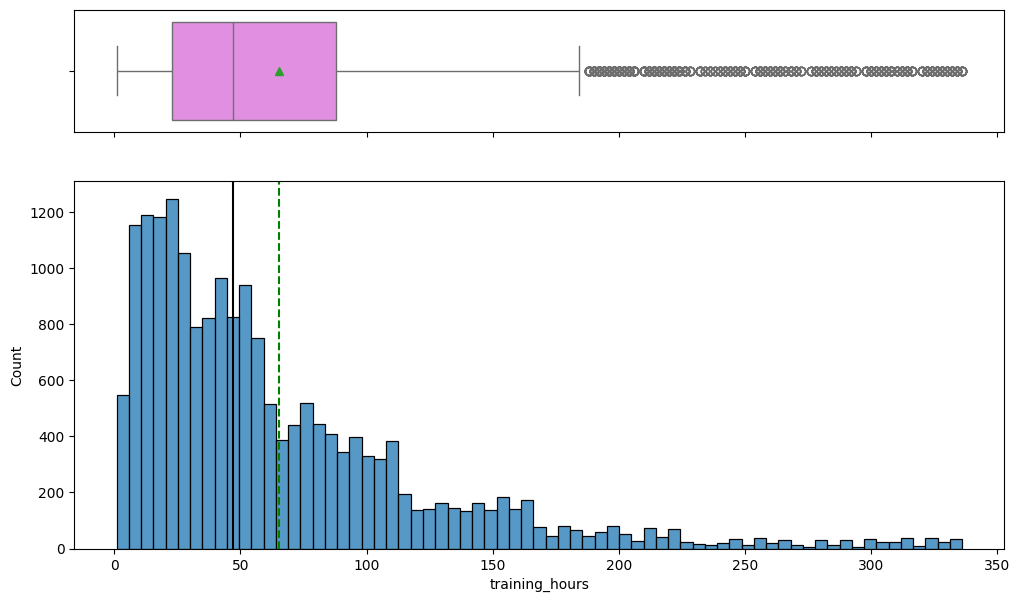

In [75]:
histogram_boxplot(df, 'training_hours');

<b>Observation(s):</b>
<ul>
    <li>Distribution heavily skewed right</li>
    <li>Largest cluster around 25</li>
    <li>Decline in count is very gradual after 125</li>
</ul>

### Multivariate Analysis

In [76]:
df

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,last_new_job,training_hours,target
0,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,1,36,1.0
1,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,>4,47,0.0
2,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,never,83,0.0
3,0.789,Unknown,No relevent experience,no_enrollment,Graduate,Business Degree,<1,never,52,1.0
4,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,4,8,0.0
...,...,...,...,...,...,...,...,...,...,...
19153,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,1,42,1.0
19154,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,4,52,1.0
19155,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,4,44,0.0
19156,0.802,Male,Has relevent experience,no_enrollment,High School,Unknown,<1,2,97,0.0


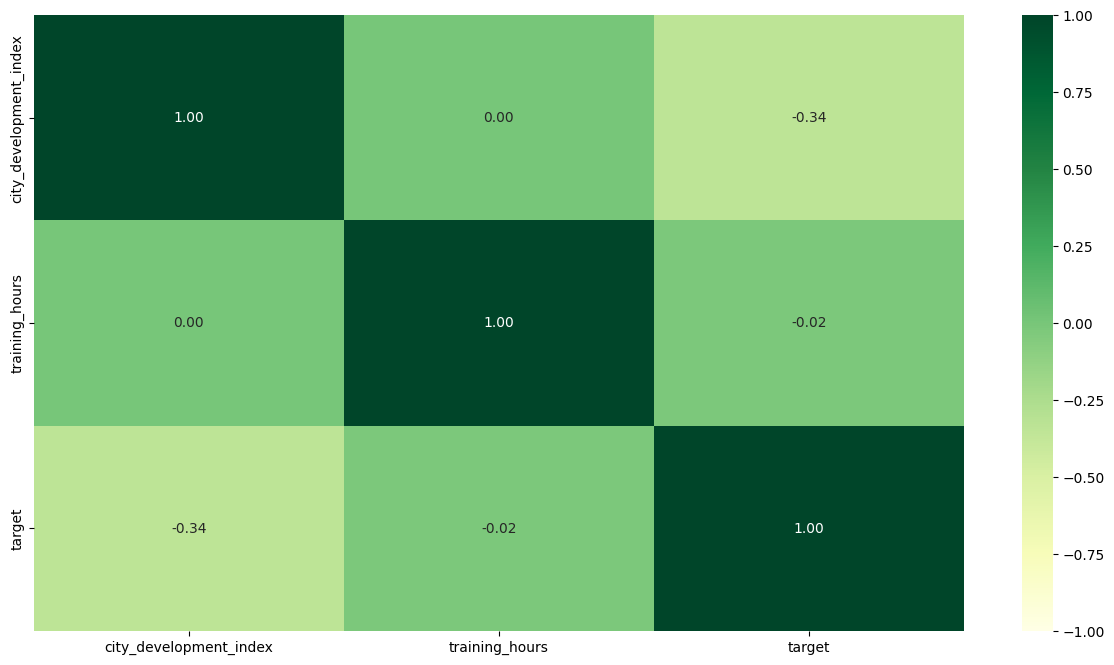

In [77]:
# Correlation heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="YlGn")
plt.show()

<b>Observation(s):</b>
<ul>
    <li>Not particularly helpful, given the small number of numerical columns</li>
    <li>There are no noteworthy correlations</li>
</ul>

<b>target x gender</b>

target     0.0   1.0    All
gender                     
All      14190  4718  18908
Male     10177  3008  13185
Unknown   2965  1335   4300
Female     911   326   1237
Other      137    49    186
------------------------------------------------------------------------------------------------------------------------


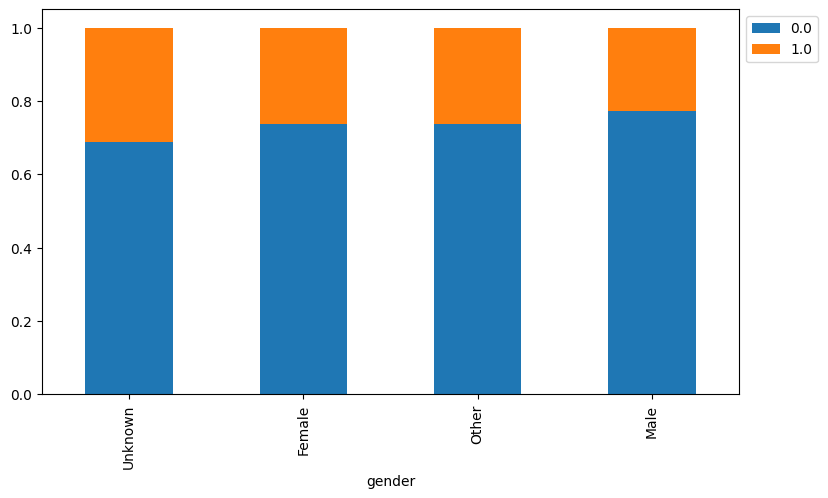

In [78]:
stacked_barplot(df, 'gender', 'target')

<b>Observation(s):</b>
<ul>
    <li>There is no considerable difference between the unique values.</li>
</ul>

<b>target x relevent_experience</b>

target                     0.0   1.0    All
relevent_experience                        
All                      14190  4718  18908
Has relevent experience  10794  2940  13734
No relevent experience    3396  1778   5174
------------------------------------------------------------------------------------------------------------------------


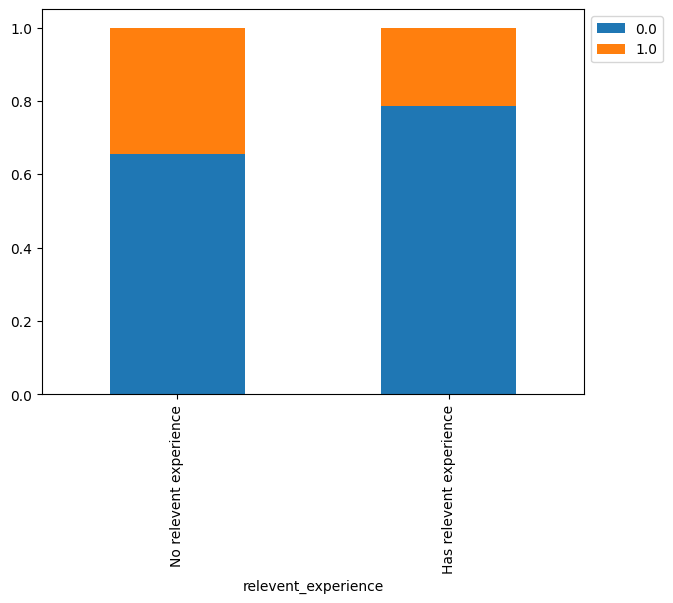

In [79]:
stacked_barplot(df, 'relevent_experience', 'target')

<b>Observation(s):</b>
<ul>
    <li>Candidates with no relevant experience were slightly more likey to desire the new job</li>
</ul>

<b>target x enrolled_university</b>

target                 0.0   1.0    All
enrolled_university                    
All                  14190  4718  18908
no_enrollment        10998  3002  14000
Full time course      2301  1418   3719
Part time course       891   298   1189
------------------------------------------------------------------------------------------------------------------------


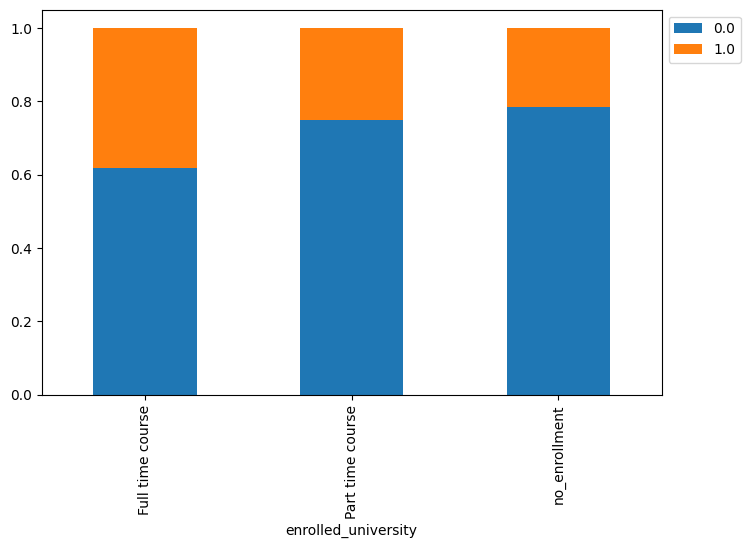

In [80]:
stacked_barplot(df, 'enrolled_university', 'target')

<b>Observation(s):</b>
<ul>
    <li>Candidates enrolled full time were most likely to desire the new job</li>
    <li>Candidates enrolled part time and not enrolled at all were equally likely</li>
</ul>

<b>target x education_level</b>

target             0.0   1.0    All
education_level                    
All              14190  4718  18908
Graduate          8571  3304  11875
Masters           3423   934   4357
High School       1580   383   1963
Phd                355    58    413
Primary School     261    39    300
------------------------------------------------------------------------------------------------------------------------


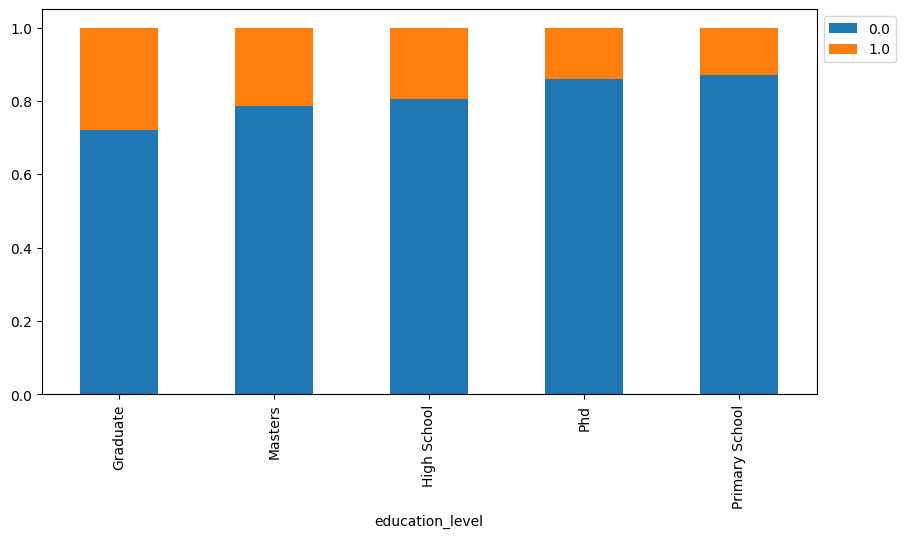

In [81]:
stacked_barplot(df, 'education_level', 'target')

<b>Observation(s):</b>
<ul>
    <li>College graduates were most likely to desire the new job, by a small margin</li>
    <li>All other values were roughly equal in likelihood</li>
</ul>

<b>target x major_discipline</b>

target              0.0   1.0    All
major_discipline                    
All               14190  4718  18908
STEM              10695  3788  14483
Unknown            2079   493   2572
Humanities          528   141    669
Other               279   102    381
Business Degree     241    86    327
No Major            168    55    223
Arts                200    53    253
------------------------------------------------------------------------------------------------------------------------


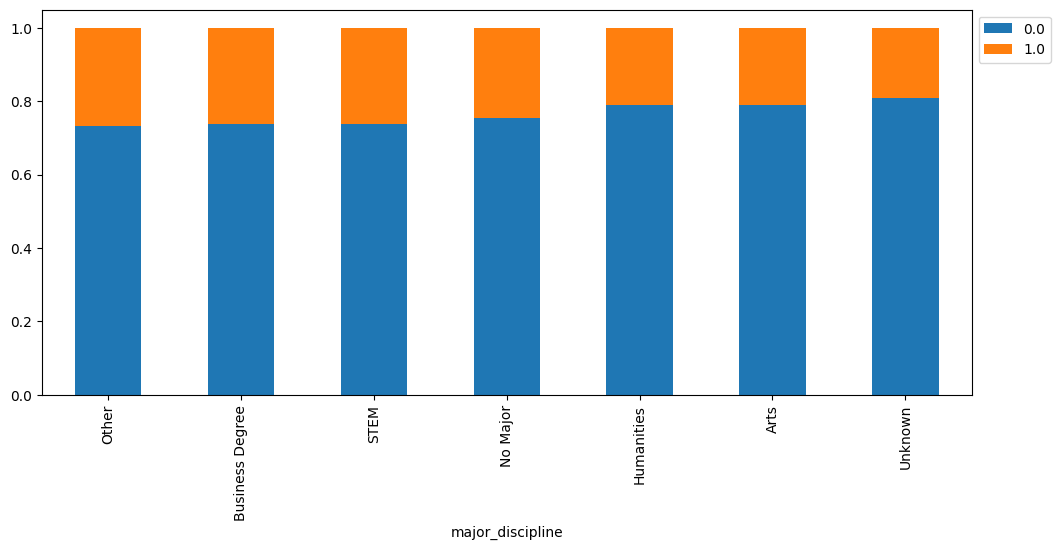

In [82]:
stacked_barplot(df, 'major_discipline', 'target')

<b>Observation(s):</b>
<ul>
    <li>There is no considerable difference between the unique values.</li>
</ul>

<b>target x experience</b>

target        0.0   1.0    All
experience                    
All         14190  4718  18908
>20          2799   516   3315
3             853   468   1321
4             929   452   1381
5            1004   407   1411
2             716   364   1080
6             864   340   1204
7             720   303   1023
<1            266   232    498
1             300   226    526
9             763   213    976
10            778   207    985
8             600   195    795
11            511   151    662
15            569   114    683
14            479   107    586
12            399    92    491
13            321    77    398
16            434    71    505
17            284    57    341
19            251    52    303
18            237    41    278
20            113    33    146
------------------------------------------------------------------------------------------------------------------------


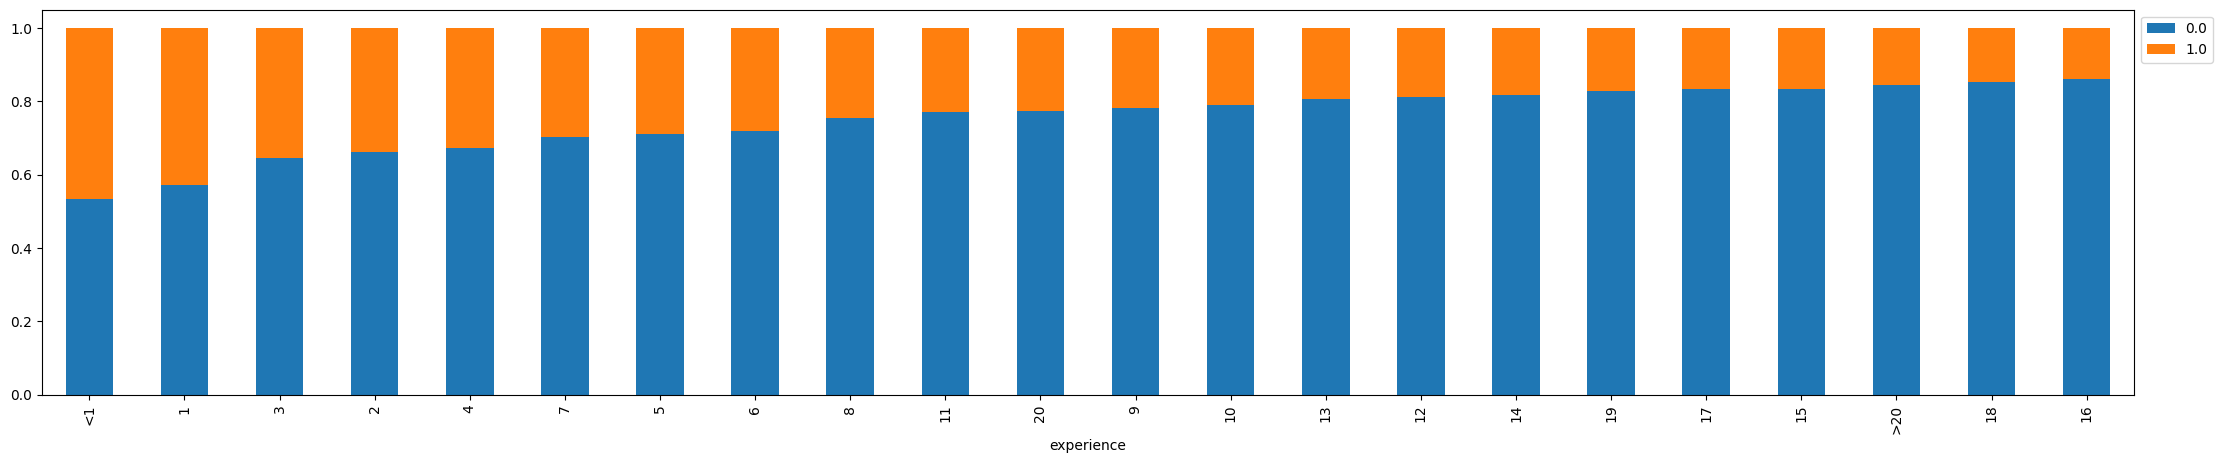

In [83]:
stacked_barplot(df, 'experience', 'target')

<b>Observation(s):</b>
<ul>
    <li>Roughly, the more years of experience the candidate had, the less likely they were to desire the new job</li>
</ul>

<b>target x last_new_job</b>

target          0.0   1.0    All
last_new_job                    
All           14190  4718  18908
1              6096  2243   8339
never          1628   723   2351
2              2192   698   2890
>4             2683   596   3279
3               790   231   1021
4               801   227   1028
------------------------------------------------------------------------------------------------------------------------


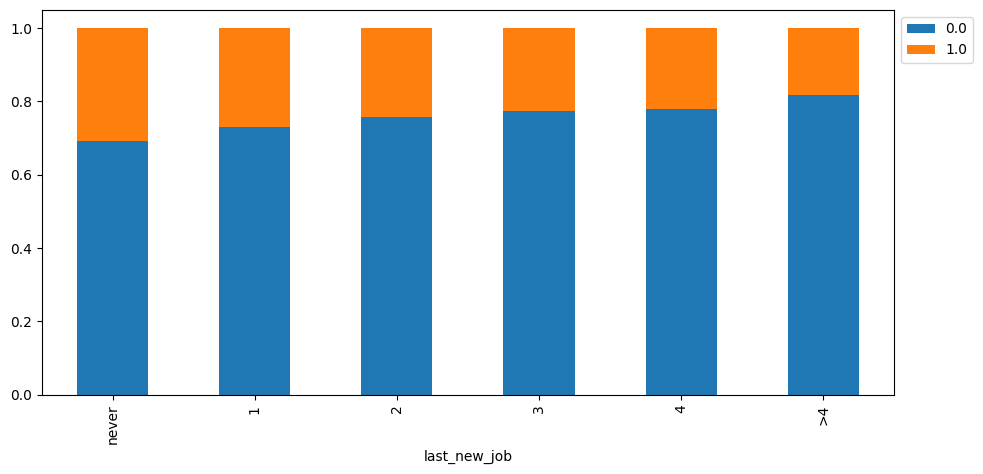

In [84]:
stacked_barplot(df, 'last_new_job', 'target')

<b>Observation(s):</b>
<ul>
    <li>The more years since their last job, the less likely they were to desire the new one</li>
</ul>

<b>target x city_development_index</b>

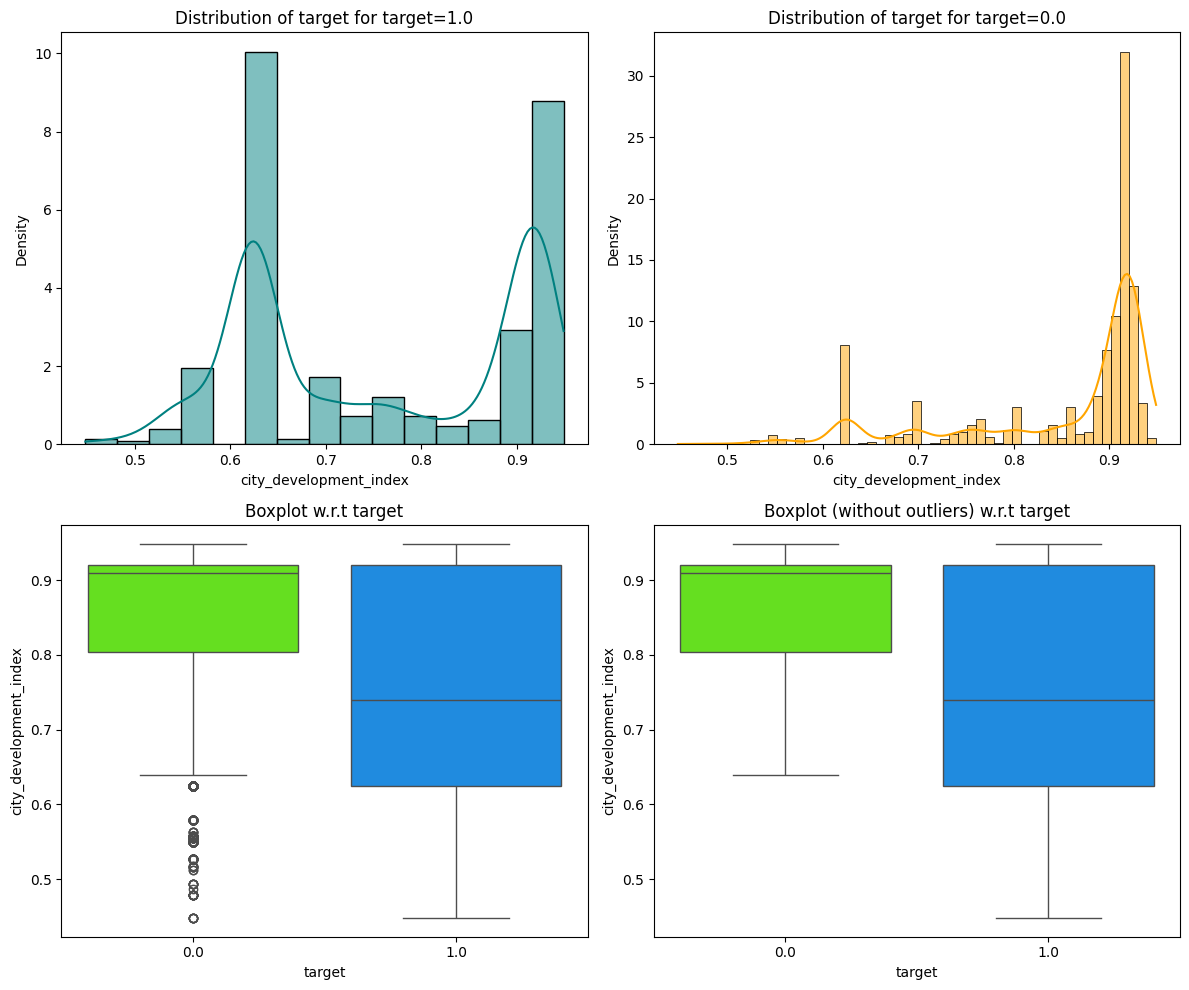

In [85]:
distribution_plot_wrt_target(df, 'city_development_index', 'target')

<b>Observation(s):</b>
<ul>
    <li>On average, candidates interested in the new job had a lower city_development_index</li>
</ul>

<b>target x training_hours</b>

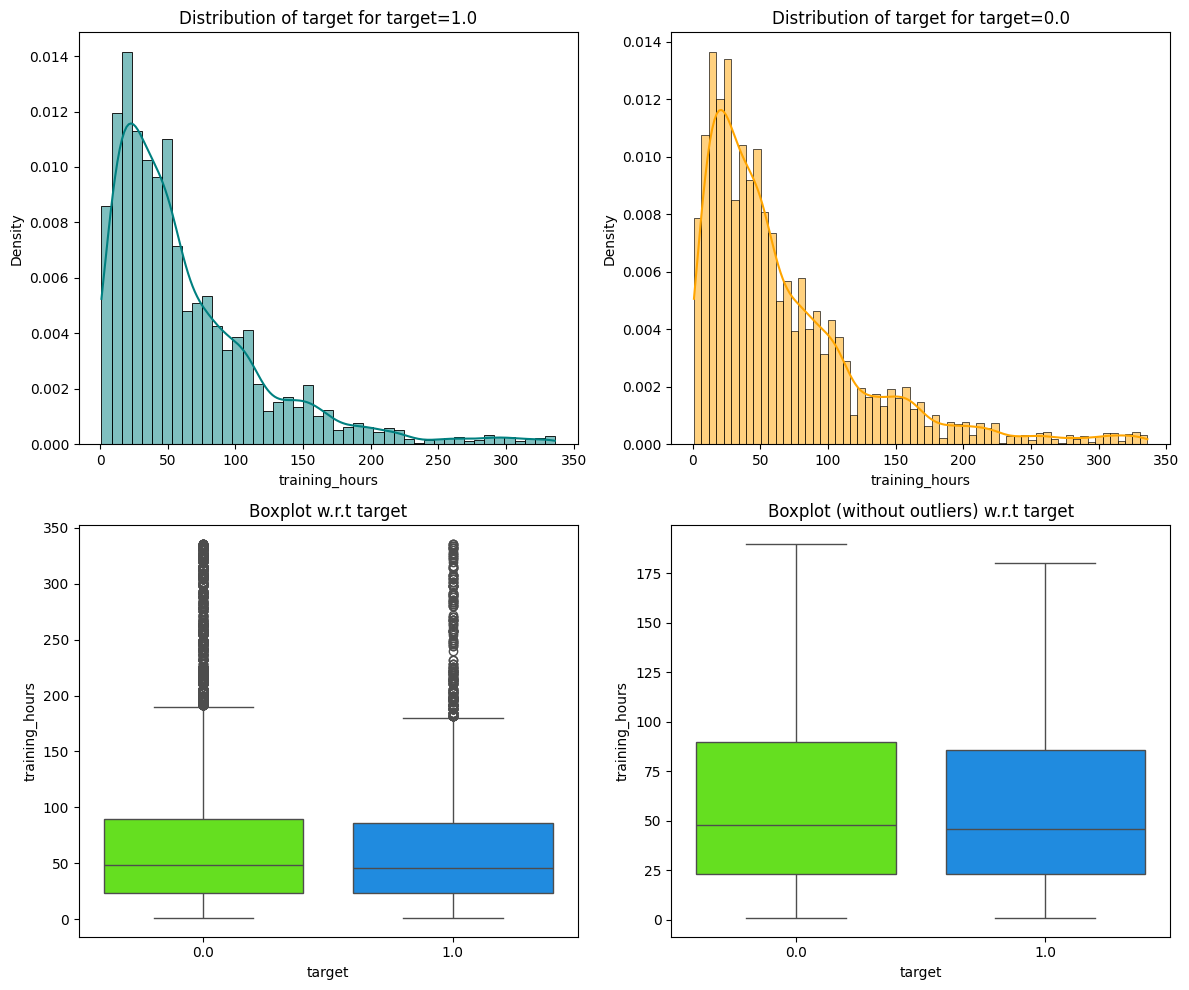

In [86]:
distribution_plot_wrt_target(df, 'training_hours', 'target')

<b>Observation(s):</b>
<ul>
    <li>There does not appear to be a considerable difference.</li>
</ul>

### EDA Conclusion

<ul>
    <li>Those interested in the job had a lower average city_development_index</li>
    <li>The more years since their last job, the less likely they were to be interested in the new job, slightly</li>
    <li>The more years of experience, the less likely they were to be interest in the new job</li>
    <li>College non-phd, non-masters college graduates were most likely to be interested in the new job</li>
    <li>Full-time students were the most likely to be interested</li>
    <li>Candidates with no relevant experience were more likely to be interested than those with relevant experience</li>
</ul>

In [87]:
df.head(10)

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,last_new_job,training_hours,target
0,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,1,36,1.0
1,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,>4,47,0.0
2,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,never,83,0.0
3,0.789,Unknown,No relevent experience,no_enrollment,Graduate,Business Degree,<1,never,52,1.0
4,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,4,8,0.0
5,0.764,Unknown,Has relevent experience,Part time course,Graduate,STEM,11,1,24,1.0
6,0.920,Male,Has relevent experience,no_enrollment,High School,Unknown,5,1,24,0.0
7,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,>4,18,1.0
8,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,1,46,1.0
9,0.920,Unknown,Has relevent experience,no_enrollment,Graduate,STEM,17,>4,123,0.0


## Feature Engineering

### Normalization/Encoding

#### gender

In [99]:
# Encoding gender
df = pd.get_dummies(df, columns=['gender'], drop_first=True)

#### relevent_experience

In [100]:
# Encoding relevent_experience
df = pd.get_dummies(df, columns=['relevent_experience'], drop_first=True)

#### enrolled_university

In [90]:
# Encoding enrolled_university
df = pd.get_dummies(df, columns=['enrolled_university'], drop_first=True)

#### education_level

In [91]:
# Encoding education_level
df['education_level'] = label_encoder.fit_transform(df['education_level'])

#### major_discipline

In [92]:
# Encoding major_discipline
df['major_discipline'] = label_encoder.fit_transform(df['major_discipline'])

#### experience

In [93]:
# Encoding experience
df['experience'] = label_encoder.fit_transform(df['experience'])

#### last_new_job

In [94]:
# Encoding last_new_job
df['last_new_job'] = label_encoder.fit_transform(df['last_new_job'])

#### city_development_index

In [95]:
# Normalizing city_development_index
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(df[['city_development_index']])
df[['city_development_index']] = scaler.transform(df[['city_development_index']])

#### training_hours

In [96]:
# Normalizing training_hours
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(df[['training_hours']])
df[['training_hours']] = scaler.transform(df[['training_hours']])

In [97]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
city_development_index,18908.0,0.761319,0.245607,0.0,0.582834,0.922156,0.942116,1.0
gender,18908.0,1.399249,0.908609,0.0,1.000000,1.000000,1.000000,3.0
relevent_experience,18908.0,0.273641,0.445839,0.0,0.000000,0.000000,1.000000,1.0
enrolled_university,18908.0,1.543738,0.800937,0.0,1.000000,2.000000,2.000000,2.0
education_level,18908.0,0.693675,0.997425,0.0,0.000000,0.000000,2.000000,4.0
major_discipline,18908.0,4.850063,1.053845,0.0,5.000000,5.000000,5.000000,6.0
experience,18908.0,12.935530,6.614511,0.0,7.000000,14.000000,19.000000,21.0
last_new_job,18908.0,1.739317,1.927771,0.0,0.000000,1.000000,4.000000,5.0
training_hours,18908.0,0.192179,0.179300,0.0,0.065672,0.137313,0.259701,1.0
target,18908.0,0.249524,0.432749,0.0,0.000000,0.000000,0.000000,1.0


In [98]:
df.head(10)

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,last_new_job,training_hours,target
0,0.942116,1,0,2,0,5,21,0,0.104478,1.0
1,0.654691,1,1,2,0,5,6,4,0.137313,0.0
2,0.351297,3,1,0,0,5,15,5,0.244776,0.0
3,0.680639,3,1,2,0,1,20,5,0.152239,1.0
4,0.636727,1,0,2,2,5,21,3,0.020896,0.0
5,0.630739,3,0,1,0,5,2,0,0.068657,1.0
6,0.942116,1,0,2,1,6,15,0,0.068657,0.0
7,0.626747,1,0,2,0,5,4,4,0.050746,1.0
8,0.942116,1,0,2,0,5,17,0,0.134328,1.0
9,0.942116,3,0,2,0,5,8,4,0.364179,0.0


### Feature Engineering  Final Thoughts

<ul>
    <li>Used get_dummies to encode gender, relevent_experience, and enrolled_university, since they have three or less unique values.</li>
    <li>Considered binning years of experience, to get a clearer idea of the discrepancy between certain gaps. However, there is already a very clear trend in the likelihood that a candidate is interested in the new job, so there's no need to do this.</li>
    <li>Used min-max normalization throughout, as none of the distributions for numerical columns are fully gausian, making them a bad fit for standardization. Logarithmic could be used, but did not seem entirely necessary.</li>
</ul>